In [12]:
%load_ext autoreload 
%autoreload 2

import os
import math
import numpy as np
import pandas as pd
from numpy import array
from numpy import array, arange, abs as np_abs
from numpy.fft import rfft, rfftfreq
from math import sin, pi
from scipy import signal
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import importlib
import model as md
import view as vw

importlib.reload(md)
importlib.reload(vw)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<module 'view' from 'c:\\Users\\Артем\\Desktop\\Вуз\\Аспирантура\\Диссертация\\Алгоритм\\Relaxation_frequency_phase_algorithm\\view\\__init__.py'>

In [13]:
dir = os.getcwd()
U_path = os.path.join(dir, "data","real", "RTB2004_CHAN1.csv")
I_path= os.path.join(dir, "data","real", "RTB2004_CHAN2.csv")

t,U = md.make_real_data_list(U_path)
t,I = md.make_real_data_list(I_path)

In [14]:
F,V = md.get_spectrum3(t,U)
F_peak_calc = F[np.argmax(V)]
T=1/F_peak_calc
T_counts=md.convert_to_counts(t,T)

In [15]:
print(len(U)/T_counts)

53.304904051172706


In [16]:
window=T_counts*20
fs = 1 / np.mean(np.diff(t))
vw.show_I_U_3(t,I,U,0,window)


In [17]:
t_f, U_f=md.filter_butter_bandpass(t,U,F_peak_calc,200e3,2)
t_f, I_f=md.filter_butter_bandpass(t,I,F_peak_calc,200e3,2)

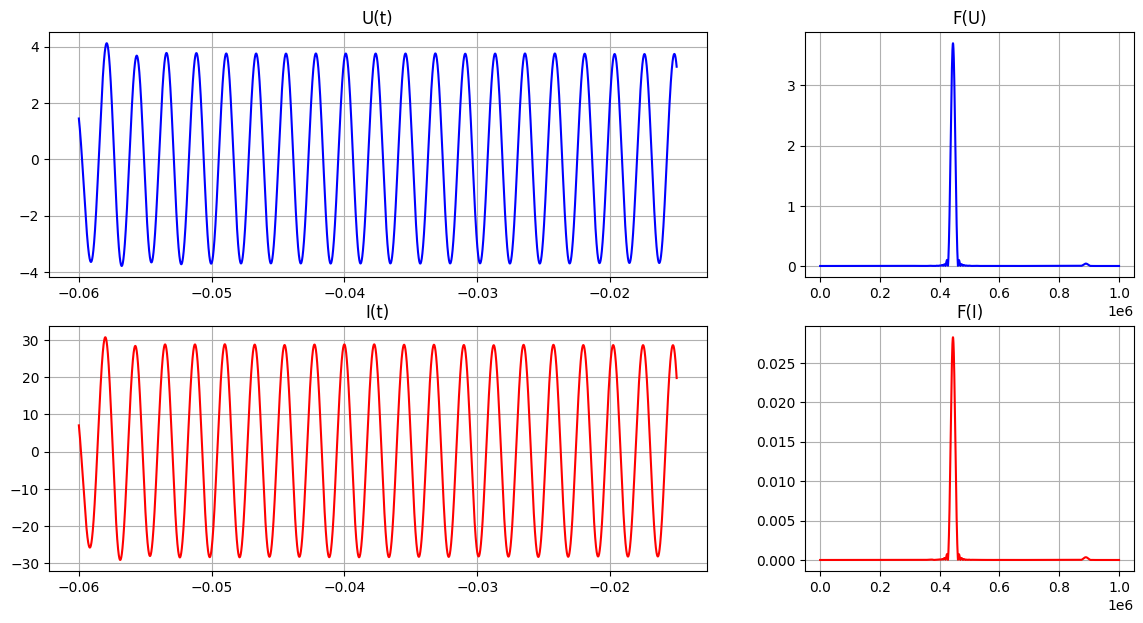

In [18]:
vw.show_I_U_2(t_f,I_f.real,U_f.real,0,window)

In [19]:
phase_methods = [
    md.get_phase_MP,
    md.get_phase_ZCRR,
    md.get_phase_FFT,
    md.get_phase_HB,
    md.get_phase_XCOR,
    md.get_phase_LI,
    md.get_phase_swf3p,
    md.get_phase_PPV,
    md.get_phase_VNA
]

In [20]:
for i in range(0,len(phase_methods),1):
    phase=phase_methods[i](t_f, I_f,U_f, F_peak_calc)
    print(phase_methods[i].__name__)
    print (" phase extimated=",phase)


get_phase_MP
 phase extimated= 16.686679536799147
get_phase_ZCRR
 phase extimated= 17.46568827260237
get_phase_FFT
 phase extimated= 17.398567011957887
get_phase_HB
 phase extimated= 17.480700910707323
get_phase_XCOR
 phase extimated= 17.3861402048873
get_phase_LI
 phase extimated= 17.430080645772776
get_phase_swf3p
 phase extimated= 17.27451121010435
get_phase_PPV
 phase extimated= 17.36079741646607
get_phase_VNA
 phase extimated= (array([-6.00000e-05, -5.99984e-05, -5.99968e-05, ...,  5.99952e-05,
        5.99968e-05,  5.99984e-05], shape=(75000,)), array([17.36079742]))
